In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
class TransformerEncoderLayerWithAttention(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None  # stores [B, num_heads, T, T] during forward

    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False):
        # is_causal is ignored since we pass explicit causal masks
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False  # [B, num_heads, T, T]
        )
        self.attn_weights = attn_weights.detach()  # store without gradients

        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TransformerPrefixSum(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=4, dim_feedforward=128, dropout=0.0):
        super().__init__()
        self.input_linear = nn.Linear(1, d_model)

        encoder_layer = TransformerEncoderLayerWithAttention(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_linear = nn.Linear(d_model, 1)

    def forward(self, src, causal_mask=False):
        # src: [B, T, 1]
        x = self.input_linear(src)  # [B, T, d_model]

        # Construct causal mask if requested
        src_mask = None
        if causal_mask:
            T = x.size(1)
            device = x.device
            src_mask = torch.triu(
                torch.ones(T, T, device=device, dtype=torch.bool),
                diagonal=1
            )  # True where masked

        x = self.encoder(x, mask=src_mask)  # [B, T, d_model]
        out = self.output_linear(x)         # [B, T, 1]
        return out

    def get_attention_maps(self):
        """
        Returns:
            List of attention maps for each layer.
            Each element is a tensor of shape [B, num_heads, T, T].
        """
        attn_maps = [layer.attn_weights for layer in self.encoder.layers]
        return attn_maps


In [131]:
def train_prefix(num_layers):
    # ----- Model, Optimizer, Criterion -----
    model = TransformerPrefixSum(
        d_model=d_model, 
        nhead=nhead, 
        num_layers=num_layers, 
        dim_feedforward=dim_feedforward
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    # ----- Training Loop -----
    losses = []
    model.train()
    total_loss = 0.0
    
    for i in range(num_batches):
        # Generate fresh integer data between 0 and 9 for training
        w = torch.randint(0, 20, (batch_size, T, 1), device=device, dtype=torch.float32) / 20
        # [B, T, 1]
        prefix_sum = torch.cumsum(w, dim=1)                                              # [B, T, 1]
        input_seq = w
        target_seq = prefix_sum
    
        optimizer.zero_grad()
        output = model(input_seq, causal_mask=True)                                      # [B, T, 1]
        loss = criterion(output, target_seq)
        loss.backward()
        optimizer.step()
    
        total_loss += loss.item() * batch_size
        avg_loss = total_loss / ((i + 1) * batch_size)
        losses.append(np.sqrt(avg_loss/T))
    
        if i % 100 == 0:
            print(f"Step {i+1}/{num_batches}, Avg Loss: {np.sqrt(avg_loss/T):.6f}")
    
    # ----- Plotting Loss Curve -----
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.xlabel('Training Step')
    plt.ylabel('Average MSE Loss')
    plt.title('Transformer Prefix Sum Training Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ----- Testing on a New Example -----
    model.eval()
    with torch.no_grad():
        # Generate test data matching the training distribution
        w_test = torch.randint(0, 20, (1, T, 1), device=device, dtype=torch.float32) / 20  # [1, T, 1]
        pred = model(w_test, causal_mask=True).squeeze(0).squeeze(-1).cpu()            # [T]
        true_prefix_sum = torch.cumsum(w_test.squeeze(0).squeeze(-1).cpu(), dim=0)     # [T]
    
    plt.figure(figsize=(6,4))
    plt.plot(true_prefix_sum, label='True Prefix Sum', marker='o')
    plt.plot(pred, label='Transformer Prediction', linestyle='dashed', marker='x')
    plt.xlabel('Position')
    plt.ylabel('Value')
    plt.legend()
    plt.title('Prefix Sum Prediction: Transformer vs True')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    model.eval()
    with torch.no_grad():
        w_test = torch.randn(1, T, 1, device=device)   # single test sequence
        pred = model(w_test, causal_mask=True)
    
    # Extract attention maps
    attn_maps = model.get_attention_maps()  # List[Tensor], one per layer
    
    head_idx = 0     # visualize the first head
    
    fig, axs = plt.subplots(1, len(attn_maps), figsize=(5*len(attn_maps), 5))
    for l, attn in enumerate(attn_maps):
        sns.heatmap(attn[0, head_idx].cpu(), cmap="viridis", ax=axs[l])
        axs[l].set_title(f"Layer {l}, Head {head_idx}")
        axs[l].set_xlabel("Key")
        axs[l].set_ylabel("Query")
    plt.tight_layout()
    plt.show()
    
    return model

In [142]:
# ----- Hyperparameters -----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
d_model = 8
nhead = 1
dim_feedforward = 32
batch_size = 128
T = 64
num_batches = 10000
learning_rate = 1e-3

C:\Users\User\anaconda3\envs\LLM\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Step 1/10000, Avg Loss: 2.284933
Step 101/10000, Avg Loss: 2.075753
Step 201/10000, Avg Loss: 1.985507
Step 301/10000, Avg Loss: 1.897834
Step 401/10000, Avg Loss: 1.806946
Step 501/10000, Avg Loss: 1.719433
Step 601/10000, Avg Loss: 1.637681
Step 701/10000, Avg Loss: 1.563859
Step 801/10000, Avg Loss: 1.495108
Step 901/10000, Avg Loss: 1.430136
Step 1001/10000, Avg Loss: 1.371374
Step 1101/10000, Avg Loss: 1.318312
Step 1201/10000, Avg Loss: 1.270620
Step 1301/10000, Avg Loss: 1.227719
Step 1401/10000, Avg Loss: 1.188723
Step 1501/10000, Avg Loss: 1.153714
Step 1601/10000, Avg Loss: 1.121970
Step 1701/10000, Avg Loss: 1.092538
Step 1801/10000, Avg Loss: 1.065786
Step 1901/10000, Avg Loss: 1.040920
Step 2001/10000, Avg Loss: 1.017726
Step 2101/10000, Avg Loss: 0.996104
Step 2201/10000, Avg Loss: 0.976102
Step 2301/10000, Avg Loss: 0.957135
Step 2401/10000, Avg Loss: 0.939535
Step 2501/10000, Avg Loss: 0.923132
Step 2601/10000, Avg Loss: 0.907580
Step 2701/10000, Avg Loss: 0.892908
Step

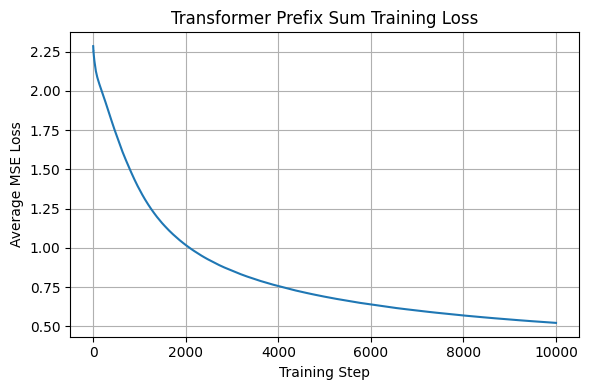

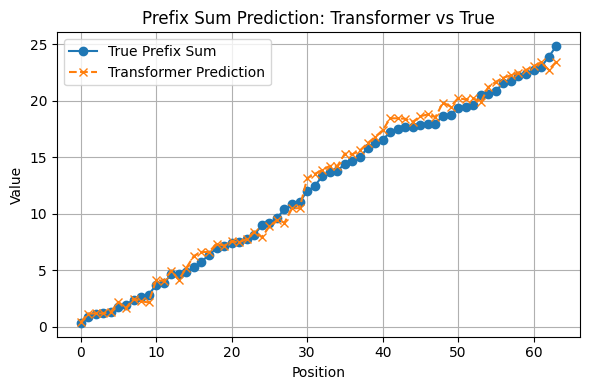

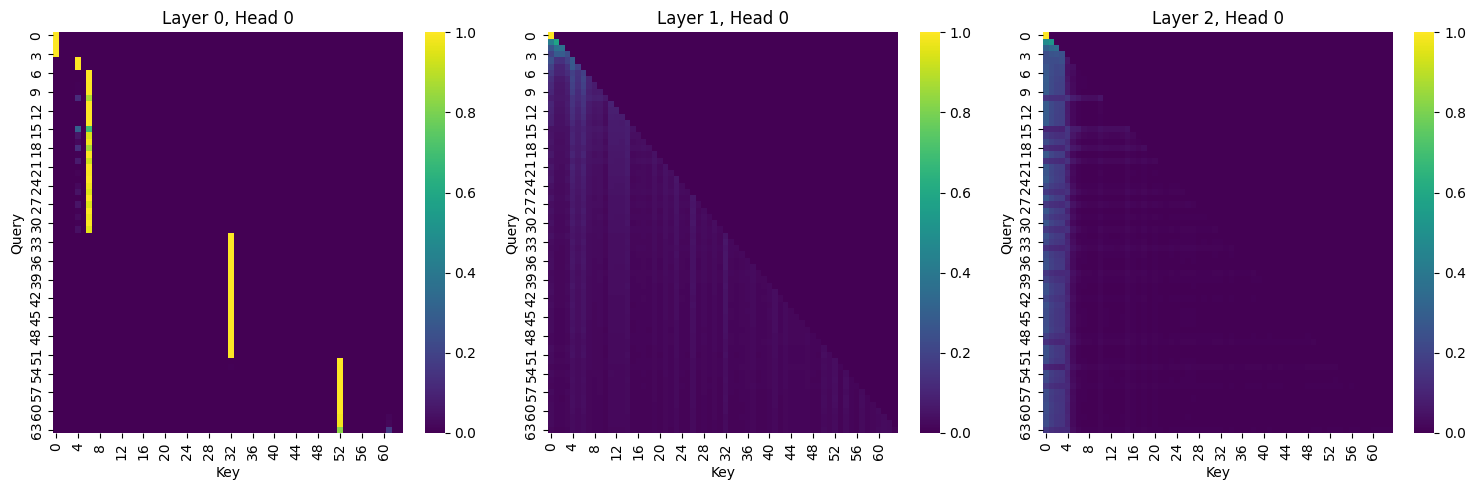

In [143]:
model = train_prefix(3)

C:\Users\User\anaconda3\envs\LLM\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


Step 1/10000, Avg Loss: 2.152967
Step 101/10000, Avg Loss: 1.520819
Step 201/10000, Avg Loss: 1.344958
Step 301/10000, Avg Loss: 1.215696
Step 401/10000, Avg Loss: 1.121223
Step 501/10000, Avg Loss: 1.037814
Step 601/10000, Avg Loss: 0.972072
Step 701/10000, Avg Loss: 0.917764
Step 801/10000, Avg Loss: 0.873839
Step 901/10000, Avg Loss: 0.836624
Step 1001/10000, Avg Loss: 0.804210
Step 1101/10000, Avg Loss: 0.776149
Step 1201/10000, Avg Loss: 0.751379
Step 1301/10000, Avg Loss: 0.728906
Step 1401/10000, Avg Loss: 0.708592
Step 1501/10000, Avg Loss: 0.690666
Step 1601/10000, Avg Loss: 0.674359
Step 1701/10000, Avg Loss: 0.659395
Step 1801/10000, Avg Loss: 0.645161
Step 1901/10000, Avg Loss: 0.632462
Step 2001/10000, Avg Loss: 0.620877
Step 2101/10000, Avg Loss: 0.610696
Step 2201/10000, Avg Loss: 0.600445
Step 2301/10000, Avg Loss: 0.592260
Step 2401/10000, Avg Loss: 0.584140
Step 2501/10000, Avg Loss: 0.575933
Step 2601/10000, Avg Loss: 0.567456
Step 2701/10000, Avg Loss: 0.559433
Step

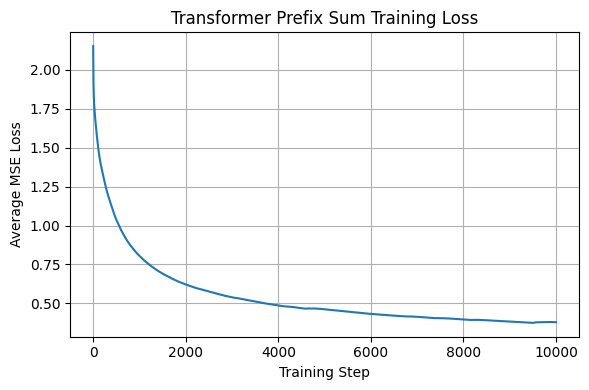

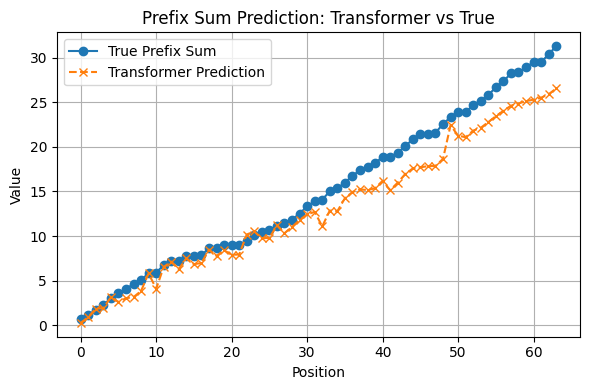

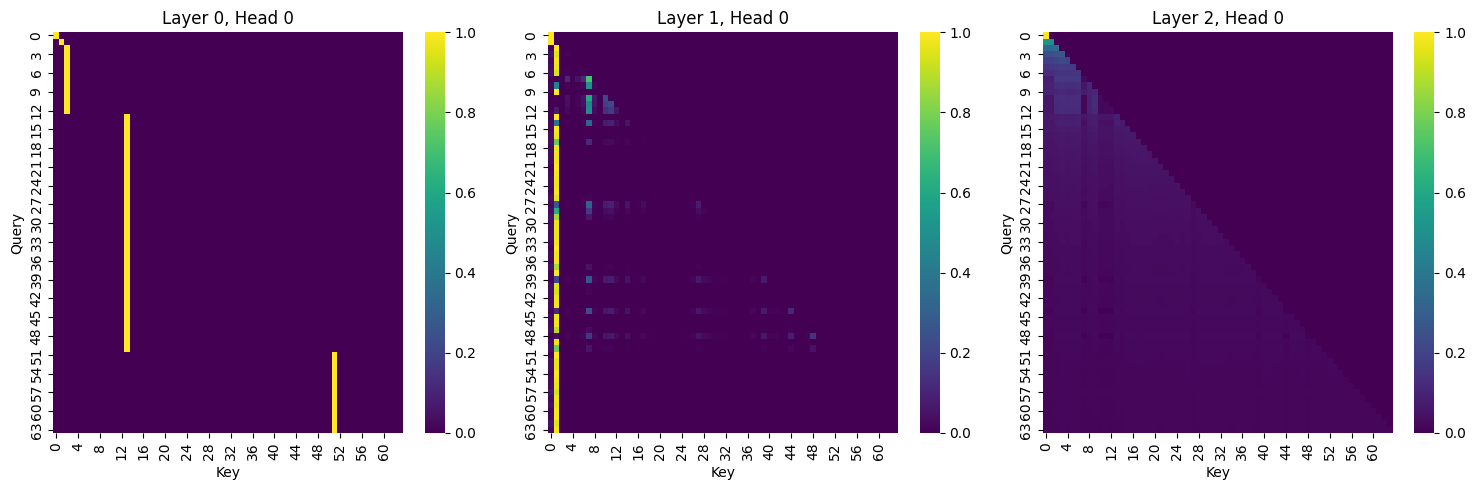

In [141]:
model = train_prefix(3)